In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import signal
from scipy.signal import welch, csd, TransferFunction

# Generate System

In [2]:
# system parameters
m = 1.0
c = 0.5
k = 4.0

In [8]:
# old model
a1 = -k/m
a2 = -c/m
b1 = 1/m

print(f"a1 = {a1}, a2 ={a2}, b1 = {b1}")

# new model
# a1 = 
# a2 = 
# b1 = 
# b2 = 

a1 = -4.0, a2 =-0.5, b1 = 1.0


In [3]:
def F(t):
    u = 0.25 * np.random.randn()
    return u

In [4]:
def mass_spring_damp(t, state):
    # x(state) = x1, x1_dot
    x, x_dot, _ = state
    # m*x_ddot + c*x_dot + k*x = F (x = mass displacement)
    u = F(t)
    x_ddot = 1/m * (u - c * x_dot - k * x)
    return [x_dot, x_ddot, u]

# Simulate System and Generate Data

In [5]:
# setup simulation parameters
t_span = (0, 10)
t = np.linspace(t_span[0], t_span[1], 1000)
x0 = [0.0, 0.0, 0] # 1m, 0m/s

sol = solve_ivp(mass_spring_damp, t_span, x0, t_eval=t)

fs = 400 #Hz - sampling freqency, 200 old
sol_freq = np.fft.fftfreq(len(t), 1/fs)
sol_out_fft = np.fft.fft(sol.y[0])
sol_in_fft = np.fft.fft(sol.y[2])

# take real parts from signal
half_n = len(t)//2
fft_freq = sol_freq[:half_n]
sol_out_fft_mag = 1 / half_n * np.abs(sol_out_fft[:half_n])

# plotting tf
sol_tf = sol_out_fft / sol_in_fft
sol_tf_mag = 1/half_n * np.abs(sol_tf[:half_n])

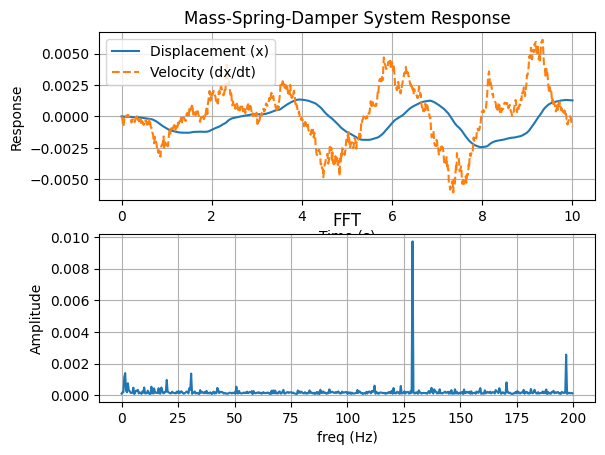

In [6]:
# view dynamics response and fft
plt.subplot(2,1,1)
plt.plot(sol.t, sol.y[0], label='Displacement (x)')
plt.plot(sol.t, sol.y[1], label='Velocity (dx/dt)', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Mass-Spring-Damper System Response')
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(fft_freq, sol_tf_mag)
plt.title('FFT')
plt.xlabel('freq (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

c:\Users\alexa\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


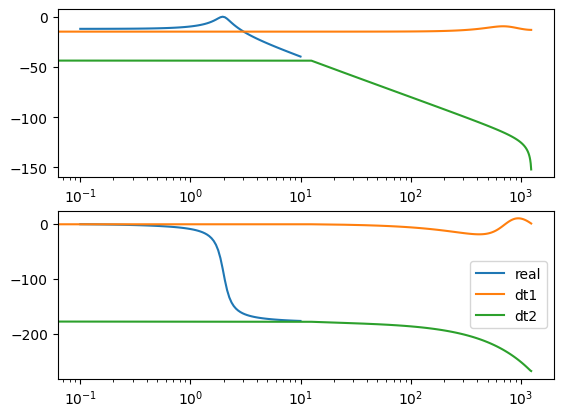

In [ ]:
num_real = 1
den_real = [m, c, k]

sys_real = TransferFunction(num_real, den_real)
sys_d = TransferFunction(num_real, den_real, dt = 1/fs)
sys_d2 = sys_real.to_discrete(dt=1/fs, method='zoh')

w_r, mag_r, phase_r = signal.bode(sys_real)
w_d, mag_d, phase_d = signal.dbode(sys_d)
w_d2, mag_d2, phase_d2 = signal.dbode(sys_d2)

plt.subplot(2,1,1)
plt.semilogx(w_r, mag_r)    # Bode magnitude plot
plt.semilogx(w_d, mag_d)
plt.semilogx(w_d2, mag_d2)
plt.subplot(2,1,2)
plt.semilogx(w_r, phase_r)  # Bode phase plot
plt.semilogx(w_d, phase_d) 
plt.semilogx(w_d2, phase_d2) 
plt.legend(['real', 'dt1', 'dt2'])
plt.show()

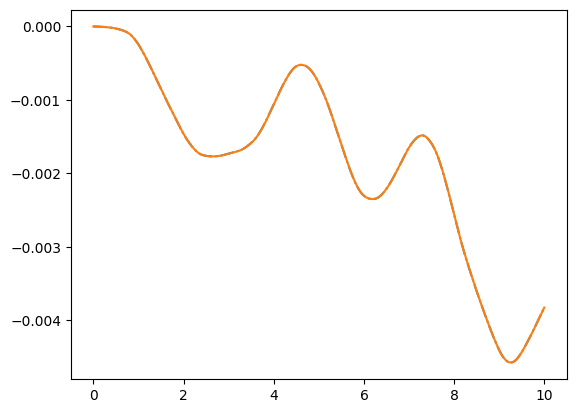

In [43]:
u = sol.y[2]
t = t = np.linspace(t_span[0], t_span[1], 1000)
tout, yout, xout = signal.lsim(sys_real, U=u, T=t)
tout_d, yout_d = signal.dlsim(sys_d, u, t=t) #
tout_d2, yout_d2 = signal.dlsim(sys_d2, u, t=t)

plt.figure()
plt.plot(tout, yout, "-.")
#plt.plot(tout_d, yout_d)
plt.plot(tout_d2, yout_d2)

# Step 1: Determine a Transfer Function

## Idea 1.1 SPA

In [8]:
# Assuming x is input data and y is output data
#fs = 100  # Sampling frequency
x = sol.y[2]
y = sol.y[0]

f, pxx = welch(x, fs=fs)
f, pxy = csd(x, y, fs=fs)

h = pxy / pxx  # Transfer function

# Represent as a transfer function object
tf_spa = TransferFunction(np.real(h), np.array([1]), dt=1/fs)

w_spa, mag_spa, phase_spa = signal.dbode(tf_spa)

## Idea 1.2 Least-Squares using an ARX model


### System Model Derivation
Equations of Motion:
$$
m \ddot x(t) + c \dot x(t) + k x(t) = F(t)
$$

continuous TF:
$$
X(s) = \frac{1}{m s^2 + c s + k} F(s)
$$

Zero-order hold to convert to TF(z)(used MATLAB c2d)

$$
a_1 = -1.995 \\
a_2 = 0.995 \\

b_1 = 4.982e-05 \\
b_2 = 4.993e-05
$$

discrete TF:
$$
X(z) = \frac{b_1 z + b_2}{z^2 + a_1 z + a_2} F(z)
$$

difference eqn:
$$
x(k + 2) + a_1 x(k + 1) + a_2 x(k) = b_1 F(k + 1) + b_2 F(k + 2)\\

\text{is equivalent to}\\

x(t) + a_1 x(t - 1) + a_2 x(t - 2) = b_1 F(t - 1) + b_2 F(t)\\

\text{and}\\

x(t) = -a_1 x(t - 1) - a_2 x(t - 2) + b_1 F(t - 1) + b_2 F(t)
$$

### Model matching MATLAB order(2 z's, 2 p's)

In [9]:
# Build Regressor


# new model
# Phi = -x(t - 1), -x(t - 2), F(t - 1), F(t - 2)
# theta = a1, a2, b1, b2

Phi = list() # regressor matrix
Y = list() # output vector

for t in range(2, len(sol.t)):
    Phi.append([-sol.y[0][t-1], -sol.y[0][t-2], sol.y[2][t-1], sol.y[2][t-2]]) # a1, a2, b1, b2
    Y.append(sol.y[0][t])

# least squares optimization
Phi = np.array(Phi)
Y = np.array(Y)

theta_hat, _, _, _ = np.linalg.lstsq(Phi, Y, rcond=None)
a1_hat, a2_hat, b1_hat, b2_hat = theta_hat

print("Estimated Parameters:")
print(f"a1 = {a1_hat:.3f}, a2 = {a2_hat:.3f}, b1 = {b1_hat:.3f}, b2 = {b2_hat:.3f}")

print("MATLAB c2d() Parameters")
print("a1 = -1.997, a2 = 0.9975, b1 = 1.249e-05, b2 = 1.248e-05")


Estimated Parameters:
a1 = -1.993, a2 = 0.993, b1 = 0.005, b2 = -0.005
MATLAB c2d() Parameters
a1 = -1.997, a2 = 0.9975, b1 = 1.249e-05, b2 = 1.248e-05


### Higher Order Model (2 z's, 3 p's)
$$
X(z) = \frac{b_1 z + b_2}{z^3 + a_1 z^2 + a_2 z^1 + a_3} F(z)\\
$$

diff eq:
$$
x(k + 3) + a_1 x(k + 2) +a_2 x(k + 1) + a_3 x(k) = b_1 F(k + 1) + b_2 F(k)
$$

equivalent to(via time-shift):
$$
x(t) = -a_1 x(t-1)- a_2 x(t-2) - a_3 x(t-3) + b_1 F(t-2) + b_2 F(t-3)
$$


In [10]:
# Build Regressor 2, increase the order to get better fitting.
# testing can be done on SVD to determine the best order

# TF: X(s) = z(s)/p(s) F(s)
# X(z) = [b1*z^-1 + b2*z^-2] / [a1*z^-1 + a2*z^-2 + a3*z^-3] F(z)

# higher order, 3 poles, 2 zeros
# Phi_2 = -x(t-1), -x(t-2), -x(t-3), F(t-2), F(t-3)
# theta_2 = a1, a2, a3, b1, b2

Phi_2 = list()
Y_2 = list()

for t in range(3, len(sol.t)):
    Phi_2.append([-sol.y[0][t-1], -sol.y[0][t-2], -sol.y[0][t-3], sol.y[2][t-2], sol.y[2][t-3]])
    Y_2.append(sol.y[0][t])

# least squares optimization
Phi_2 = np.array(Phi_2)
Y_2 = np.array(Y_2)

theta_hat_2, _, _, _ = np.linalg.lstsq(Phi_2, Y_2, rcond=None)
a1_hat_2, a2_hat_2, a3_hat_2, b1_hat_2, b2_hat_2 = theta_hat_2

print("Estimated Parameters:")
print(f"a1 = {a1_hat_2:.3f}, a2 = {a2_hat_2:.3f}, a3 = {a3_hat_2:.3f}, b1 = {b1_hat_2:.3f}, b2 = {b2_hat_2:.3f}")

print("MATLAB c2d() Parameters")
print("a1 = -1.997, a2 = 0.9975, b1 = 1.249e-05, b2 = 1.248e-05")

Estimated Parameters:
a1 = -2.417, a2 = 1.839, a3 = -0.421, b1 = -0.002, b2 = 0.002
MATLAB c2d() Parameters
a1 = -1.997, a2 = 0.9975, b1 = 1.249e-05, b2 = 1.248e-05


In [11]:
# -------------------------
# Step 4: Simulate Identified Model
# -------------------------
N = 1000
u = sol.y[2]
y_hat_1 = np.zeros(N)
y_hat_2 = np.zeros(N)

#model 1
for t in range(2, N):
    y_hat_1[t] = -a1_hat * y_hat_1[t-1] - a2_hat * y_hat_1[t-2] + b1_hat * u[t-1] + b2_hat * u[t - 2] # rebuild the difference equation

#model 2
for t in range(3, N):
    y_hat_2[t] = -a1_hat_2 * y_hat_2[t-1] - a2_hat_2 * y_hat_2[t-2] - a3_hat_2 * y_hat_2[t-3] + b1_hat_2 * u[t-2] + b2_hat_2 * u[t - 3] # rebuild the difference equation


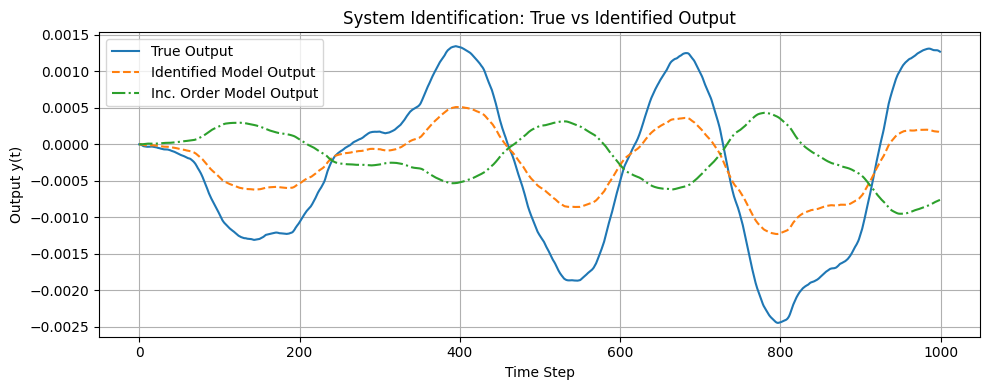

In [12]:
# -------------------------
# Step 5: Plot and Compare
# -------------------------
y = sol.y[0]
plt.figure(figsize=(10, 4))
plt.plot(y, label='True Output')
plt.plot(y_hat_1, '--', label='Identified Model Output')
plt.plot(y_hat_2, '-.', label='Inc. Order Model Output')
plt.xlabel('Time Step')
plt.ylabel('Output y(t)')
plt.legend()
plt.title('System Identification: True vs Identified Output')
plt.grid()
plt.tight_layout()
plt.show()

### Model 1 Anaysis
* the model is close, but could be closer to the system. Adding a higher order to the model might make it match even closer.
* I like that the paramters are pretty close estimations to the real system

### Model 2 Anaysis
* by adding another pole, 1/z, we have added a delay to the model, making it less accurate to the system

# Step 2 Plot the TF on a Bode

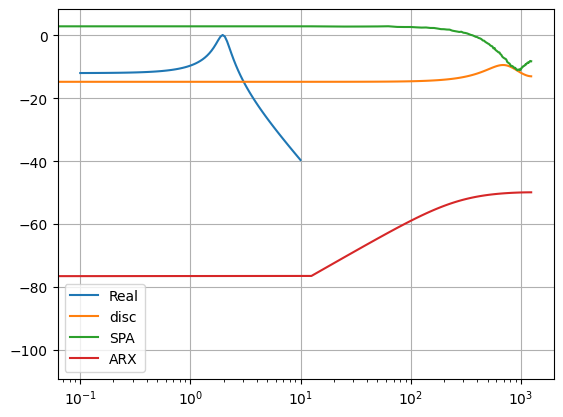

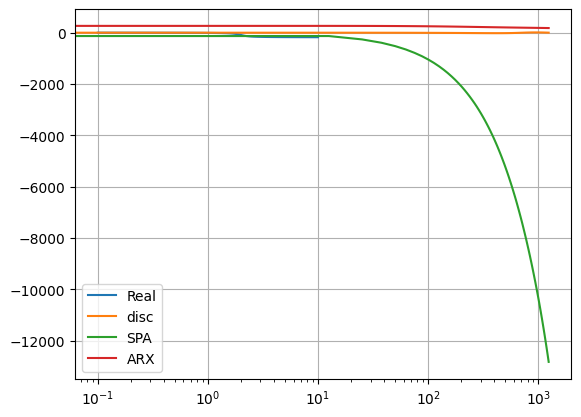

In [21]:
sys = TransferFunction([b1_hat, b2_hat], [a1_hat, a2_hat], dt = 1/fs)

w, mag, phase = signal.dbode(sys)

plt.figure()
plt.semilogx(w_r, mag_r)    # Bode magnitude plot
plt.semilogx(w_d, mag_d)
plt.semilogx(w_spa, mag_spa)
plt.semilogx(w, mag)
plt.legend(["Real", "disc", "SPA", "ARX"])
plt.grid(True)
plt.figure()
plt.semilogx(w_r, phase_r)  # Bode phase plot
plt.semilogx(w_d, phase_d)
plt.semilogx(w_spa, phase_spa)
plt.semilogx(w, phase)
plt.legend(["Real", "disc", "SPA", "ARX"])
plt.grid(True)
plt.show()


Bode Plot Analysis:
* similar to a high-pass filter, 1-st order, one pole
* b1 and b2 are basically zero
* gain is below zero and indicates that lots of frequencies get attenuated
* there is no obvious gain-crossover frequency because the gain never crosses over to the positive side of the gain magnitude. this indicateds an unconditionally stable open system
* while the time series plot shows a growing response to the input... the magnitude stays very small despite the input force taking large impacts at every time step... i.e. we are asking the system to damp out a lot(which it is) for an agressive input that can hit pretty hard and in any direction (+/-)


# Code Graveyard

Estimated Parameters:
a1 = 0.711, a2 = -0.203, b1 = 0.503


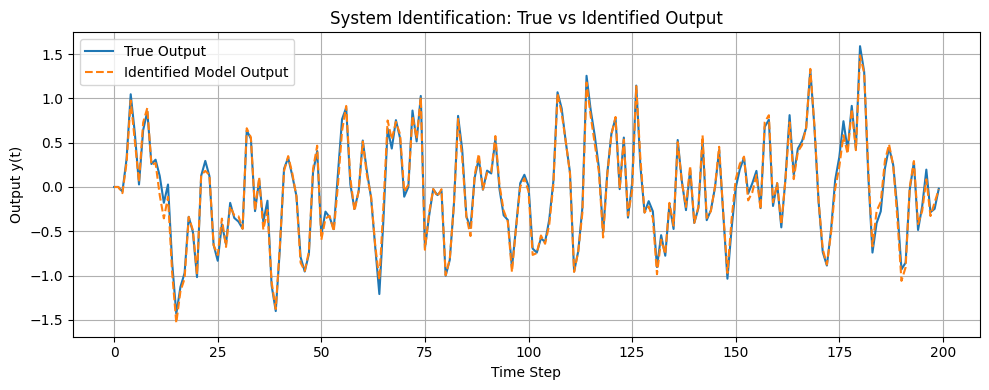

In [2]:
# chat gpt code

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# -------------------------
# Step 1: Simulate Data
# -------------------------
np.random.seed(42)

# True system: y(t) = 0.7*y(t-1) - 0.2*y(t-2) + 0.5*u(t-1)
N = 200  # number of time steps
u = np.random.randn(N)  # random input
y = np.zeros(N)

# Simulate true output with some noise
for t in range(2, N):
    y[t] = 0.7 * y[t-1] - 0.2 * y[t-2] + 0.5 * u[t-1] + 0.05 * np.random.randn()

# -------------------------
# Step 2: Build Regressor Matrix for ARX(n=2, m=1)
# y(t) = a1*y(t-1) + a2*y(t-2) + b1*u(t-1)
# -------------------------
Phi = []  # regressor matrix
Y = []    # output vector

for t in range(2, N):
    Phi.append([y[t-1], y[t-2], u[t-1]])  # [a1, a2, b1]
    Y.append(y[t])

Phi = np.array(Phi)
Y = np.array(Y)

# -------------------------
# Step 3: Least Squares Estimation
# -------------------------
theta_hat, _, _, _ = lstsq(Phi, Y, rcond=None)
a1_hat, a2_hat, b1_hat = theta_hat

print("Estimated Parameters:")
print(f"a1 = {a1_hat:.3f}, a2 = {a2_hat:.3f}, b1 = {b1_hat:.3f}")

# -------------------------
# Step 4: Simulate Identified Model
# -------------------------
y_hat = np.zeros(N)
for t in range(2, N):
    y_hat[t] = a1_hat * y_hat[t-1] + a2_hat * y_hat[t-2] + b1_hat * u[t-1]

# -------------------------
# Step 5: Plot and Compare
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(y, label='True Output')
plt.plot(y_hat, '--', label='Identified Model Output')
plt.xlabel('Time Step')
plt.ylabel('Output y(t)')
plt.legend()
plt.title('System Identification: True vs Identified Output')
plt.grid()
plt.tight_layout()
plt.show()


## Method 2: SciPy Library

In [35]:
from scipy.signal import welch, csd, TransferFunction
from scipy import signal

# Assuming x is input data and y is output data
#fs = 100  # Sampling frequency
x = sol.y[2]
y = sol.y[0]

f, pxx = welch(x, fs=fs)
f, pxy = csd(x, y, fs=fs)

h = pxy / pxx  # Transfer function

# Represent as a transfer function object
tf = TransferFunction(np.real(h), np.array([1]), dt=1/fs)

w, mag, phase = signal.dbode(tf)


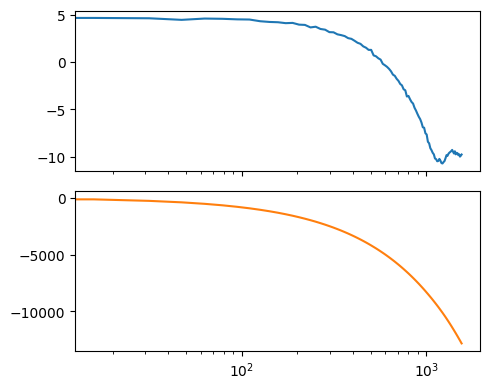

In [36]:
fg, (ax0, ax1) = plt.subplots(2, 1, sharex='all', figsize=(5, 4),
                              tight_layout=True)
ax0.semilogx(w, mag, 'C0-', label=r"$20\,\log_{10}|G(f)|$")  # Magnitude plot
ax1.semilogx(w, phase, 'C1-', label=r"$\angle G(f)$")  # Phase plot

In [23]:
tf.to_zpk()

ZerosPolesGainDiscrete(
array([ 0.96647959+0.02554337j,  0.96647959-0.02554337j,
        0.96138924+0.07925918j,  0.96138924-0.07925918j,
        0.95736825+0.12457128j,  0.95736825-0.12457128j,
        0.9526381 +0.18140302j,  0.9526381 -0.18140302j,
        0.93858918+0.23125877j,  0.93858918-0.23125877j,
        0.92371484+0.2789537j ,  0.92371484-0.2789537j ,
        0.90946141+0.33058316j,  0.90946141-0.33058316j,
        0.88710525+0.3812024j ,  0.88710525-0.3812024j ,
        0.86126552+0.42234087j,  0.86126552-0.42234087j,
        0.84088145+0.46978275j,  0.84088145-0.46978275j,
        0.81053951+0.51397346j,  0.81053951-0.51397346j,
        0.78408452+0.55026852j,  0.78408452-0.55026852j,
        0.75870207+0.59595034j,  0.75870207-0.59595034j,
        0.72736862+0.63973064j,  0.72736862-0.63973064j,
        0.68981089+0.67987229j,  0.68981089-0.67987229j,
        0.65152045+0.71442536j,  0.65152045-0.71442536j,
        0.61501332+0.74787755j,  0.61501332-0.74787755j,
       